In [2]:
import sys
sys.path.append('..')

from Pretrain import pretrain
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import json

from model_stuff import Predictor
from Rollout_BPTT import _sample_transitions, train_rollout
from SingleModel import SingleModel

import matplotlib.pyplot as plt
import numpy as np

In [9]:
best = {'n_pretrain_epochs': 12, 'train_steps': 100, 'train_horizon': 40, 'hidden_size': 64, 'dropout': 0.1430282546524271, 'lr_pretrain': 0.0016612153664944738, 'lr_rollout': 5.811111273415864e-05, 'transition_config': '200_12', 'horizon_boost': True}

In [95]:
X_df = pd.read_csv('../data/CombinedDatasetLongUnsmooth.csv')
X_df = X_df.drop(columns=['AMOC']).rename(columns={'AMOC_40N': 'AMOC'})
model_vars   = ['AMOC', 'SFWF', 'PD_200m', 'NAO']
feature_cols = target_cols = model_vars
train_cut_1, train_cut_2 = 12500, 18500
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))

y_scalers = {}
X_scaled  = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    y_scalers[var] = sc


x_scaler = StandardScaler().fit(X_df[feature_cols].values[train_idx])

In [96]:
off_to_on_threshold = 11
on_to_off_threshold = 6
search_ahead = 50
lag = 100
on_to_off1, off_to_on1, normal1 = _sample_transitions(X_df[:train_cut_1], 
                                        off_to_on_threshold=off_to_on_threshold,
                                        on_to_off_threshold=on_to_off_threshold,
                                        search_ahead=search_ahead, 
                                        lag=lag)
on_to_off2, off_to_on2, normal2 = _sample_transitions(X_df[train_cut_2:], 
                                        off_to_on_threshold=off_to_on_threshold,
                                        on_to_off_threshold=on_to_off_threshold,
                                        search_ahead=search_ahead, 
                                        lag=lag)

transitions = off_to_on1 + [w + train_cut_2 for w in off_to_on2] + on_to_off1 + [w + train_cut_2 for w in on_to_off2]
normal      = normal1 + [w + train_cut_2 for w in normal2]
print(f"off_to_on1: {len(off_to_on1)}, off_to_on2: {len(off_to_on2)}")
print(f"on_to_off1: {len(on_to_off1)}, on_to_off2: {len(on_to_off2)}")

off_to_on1: 127, off_to_on2: 129
on_to_off1: 252, on_to_off2: 114


In [98]:
model = Predictor(n_features=4, hidden_size=128, num_layers=1, dropout=best['dropout'], output_size=3)

pretrain(X_scaled, train_cut_1, train_cut_2, model,
         feature_cols, target_cols,
         lag=100, horizon=1,        
         n_epochs=10, batch_size=64,
         lr=best['lr_pretrain'], loss_fn=nn.MSELoss())

transition_prob = 0.6

losses = train_rollout(X_scaled, transition_prob, model, feature_cols, target_cols,
                       train_steps=200, lag=100, train_horizon=30,
                       loss_fn=nn.MSELoss(), lr=1e-5,
                       transitions=transitions, normal=normal, grad_clip=0.2)
              
single = SingleModel.from_trained(model, x_scaler, y_scalers)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([64, 4])) that is different to the input size (torch.Size([64, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (3) must match the size of tensor b (4) at non-singleton dimension 1

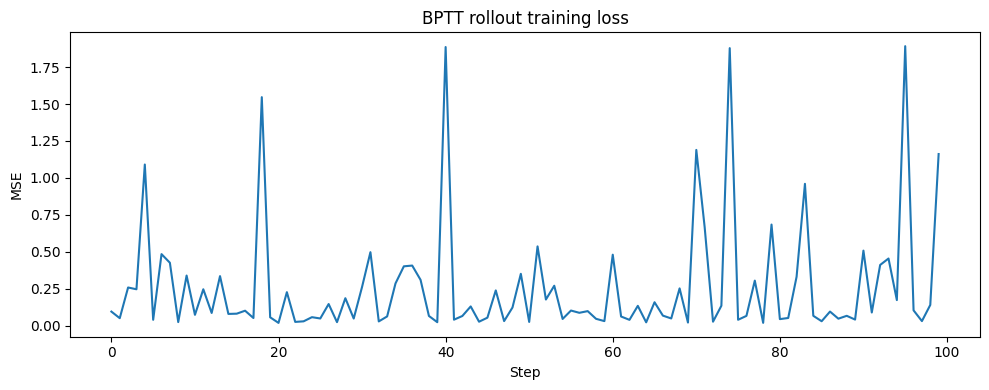

In [92]:
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('MSE')
plt.title('BPTT rollout training loss')
plt.tight_layout()
plt.show()


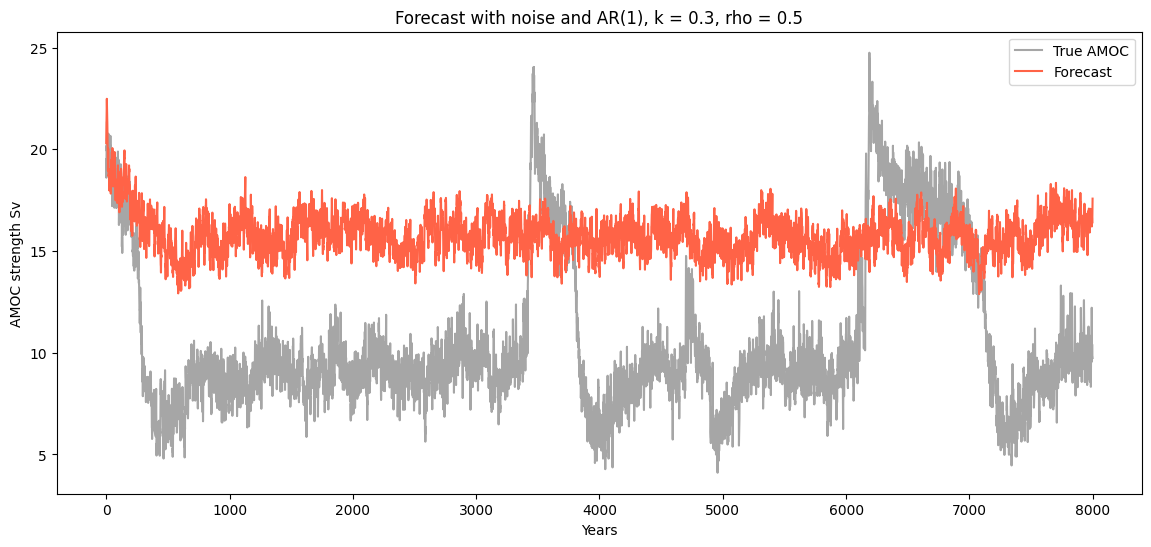

In [94]:
start_idx_on = 3000
steps = 8000

preds  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.7, k=0.01)

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X_df['AMOC'][start_idx_on:start_idx_on+steps], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()

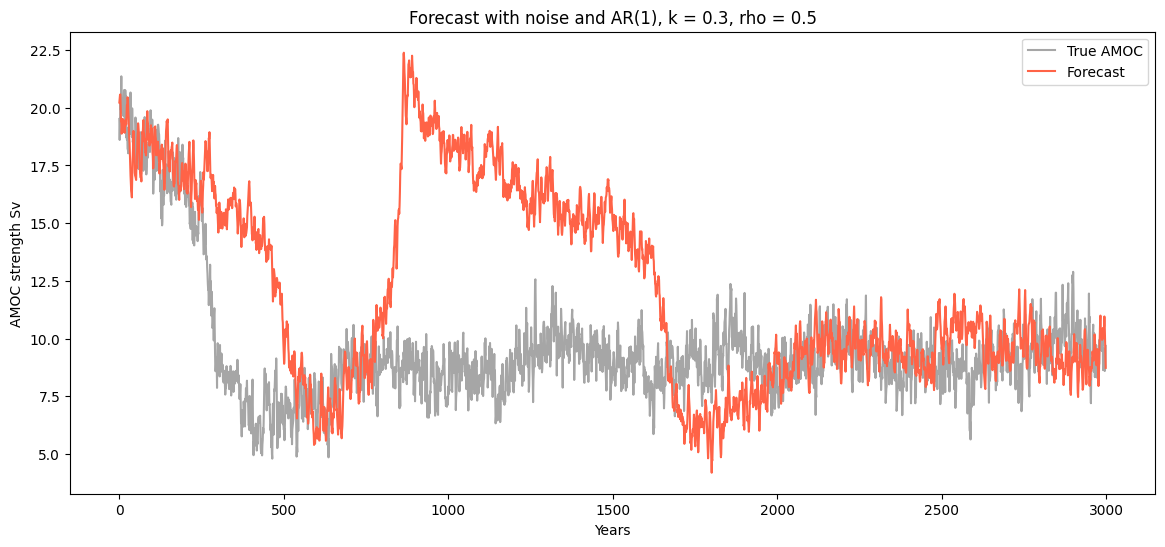

In [83]:
start_idx_on = 3000
steps = 3000

preds  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.8, k=0.01)

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X_df['AMOC'][start_idx_on:start_idx_on+steps], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()